1. Project Overview

2. Import Libraries

3. Load/Create Dataset

4. Dataset Inspection

5. Data Cleaning

6. Exploratory Data Analysis

7. Feature Engineering

8. Data Preprocessing

9. Train-Test Split

10. Model Training

11. Model Evaluation

12. Model Selection

13. Prediction Function

14. Personalized Forgetfulness Predication

15. Explainable Prediction

16. Save Model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("/content/what_did_i_forget_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5000, 12)


In [ ]:
df.head()

,trip_id,day_of_week,destination,time_of_day,weather,trip_duration,item,item_importance,item_relevance,times_carried_before,previous_forget_count,forgot
0,1,Monday,Gym,Morning,Sunny,Medium,Phone,0.98,0.656,11,0,0
1,1,Monday,Gym,Morning,Sunny,Medium,ID_Card,0.90,0.147,3,3,1
2,1,Monday,Gym,Morning,Sunny,Medium,Keys,0.93,0.469,5,0,0
3,2,Saturday,College,Morning,Hot,Short,Water_Bottle,0.45,0.964,13,1,0
4,2,Saturday,College,Morning,Hot,Short,Keys,0.93,0.519,10,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_id                5000 non-null   int64  
 1   day_of_week            5000 non-null   object 
 2   destination            5000 non-null   object 
 3   time_of_day            5000 non-null   object 
 4   weather                5000 non-null   object 
 5   trip_duration          5000 non-null   object 
 6   item                   5000 non-null   object 
 7   item_importance        5000 non-null   float64
 8   item_relevance         5000 non-null   float64
 9   times_carried_before   5000 non-null   int64  
 10  previous_forget_count  5000 non-null   int64  
 11  forgot                 5000 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 468.9+ KB


In [ ]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (5000, 12)

Missing values:
trip_id                  0
day_of_week              0
destination              0
time_of_day              0
weather                  0
trip_duration            0
item                     0
item_importance          0
item_relevance           0
times_carried_before     0
previous_forget_count    0
forgot                   0
dtype: int64

Duplicate rows: 0


In [ ]:
print("Columns in our dataset:")
print(df.columns.tolist())

Columns in our dataset:
['trip_id', 'day_of_week', 'destination', 'time_of_day', 'weather', 'trip_duration', 'item', 'item_importance', 'item_relevance', 'times_carried_before', 'previous_forget_count', 'forgot']


In [ ]:
df.describe()

,trip_id,item_importance,item_relevance,times_carried_before,previous_forget_count,forgot
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,542.734000,0.723038,0.676528,11.148200,0.652600,0.336400
std,317.445029,0.240698,0.239574,4.418206,0.985143,0.472525
min,1.000000,0.350000,0.010000,0.000000,0.000000,0.000000
25%,262.750000,0.450000,0.518000,8.000000,0.000000,0.000000
50%,544.000000,0.800000,0.744500,11.000000,0.000000,0.000000
75%,813.000000,0.950000,0.878000,14.000000,1.000000,1.000000
max,1100.000000,0.980000,0.990000,29.000000,6.000000,1.000000


In [ ]:
item_forget_rate = (
    df.groupby("item")["forgot"]
    .mean()
    .sort_values(ascending=False)
)

print("Forget rate by item:")
print((item_forget_rate * 100).round(2))

Forget rate by item:
item
Umbrella        57.18
Earphones       51.85
Water_Bottle    51.63
Charger         51.50
Notebook        44.04
Laptop          36.36
ID_Card         26.63
Keys            20.82
Wallet          16.20
Phone           10.53
Name: forgot, dtype: float64


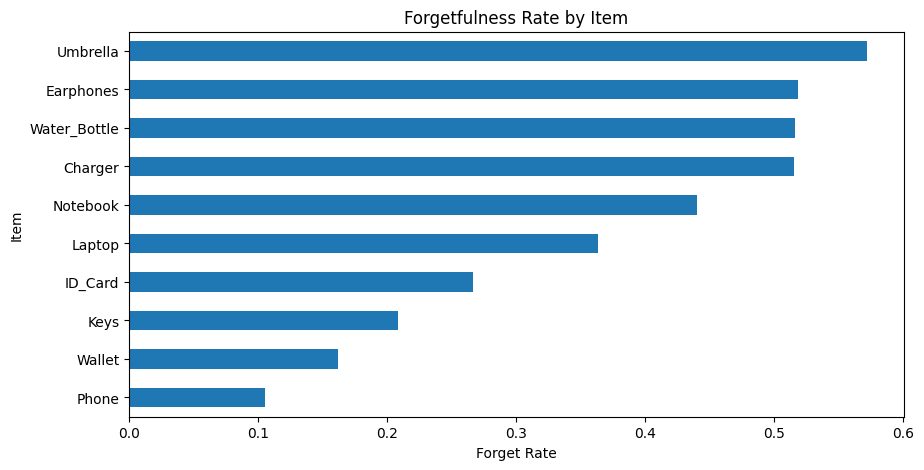

In [ ]:
plt.figure(figsize=(10, 5))

item_forget_rate.sort_values().plot(kind="barh")

plt.title("Forgetfulness Rate by Item")
plt.xlabel("Forget Rate")
plt.ylabel("Item")
plt.show()

Forget rate by destination:
destination
Other            39.81
Family_Event     38.90
Friends_House    38.16
Gym              36.10
Office           33.65
Shopping         33.07
Travel           32.92
College          28.67
Name: forgot, dtype: float64


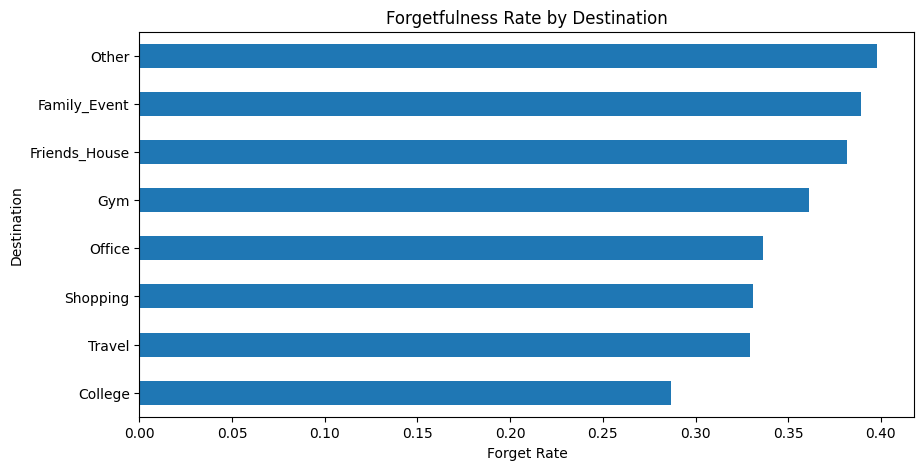

In [ ]:
destination_forget_rate = (
    df.groupby("destination")["forgot"]
    .mean()
    .sort_values(ascending=False)
)

print("Forget rate by destination:")
print((destination_forget_rate * 100).round(2))
plt.figure(figsize=(10, 5))

destination_forget_rate.sort_values().plot(kind="barh")

plt.title("Forgetfulness Rate by Destination")
plt.xlabel("Forget Rate")
plt.ylabel("Destination")
plt.show()

Forget rate by time of day:
time_of_day
Afternoon    31.04
Evening      31.10
Morning      37.73
Night        33.27
Name: forgot, dtype: float64


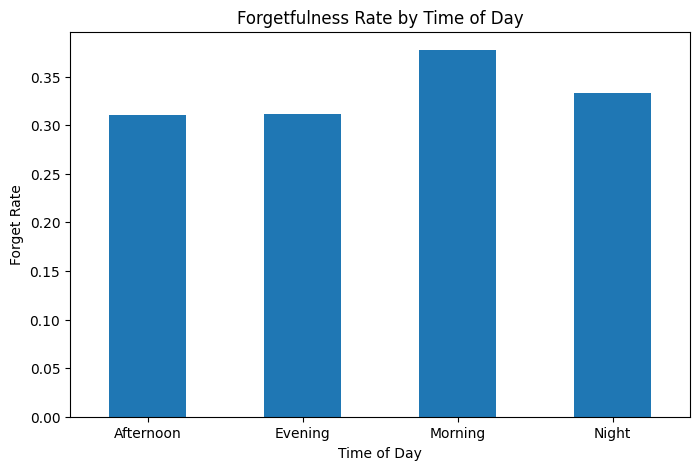

In [ ]:
time_forget_rate = (
    df.groupby("time_of_day")["forgot"]
    .mean()
)

print("Forget rate by time of day:")
print((time_forget_rate * 100).round(2))
plt.figure(figsize=(8, 5))

time_forget_rate.plot(kind="bar")

plt.title("Forgetfulness Rate by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Forget Rate")
plt.xticks(rotation=0)
plt.show()

Forget rate by weather:
weather
Cloudy    35.53
Hot       34.65
Sunny     34.41
Rainy     32.32
Cold      30.91
Name: forgot, dtype: float64


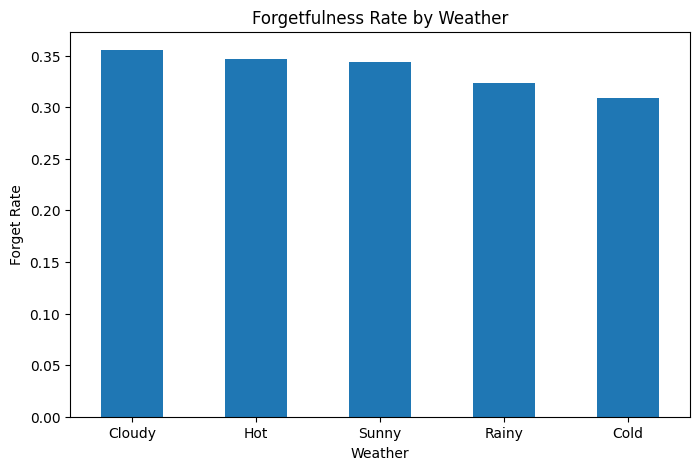

In [ ]:
weather_forget_rate = (
    df.groupby("weather")["forgot"]
    .mean()
    .sort_values(ascending=False)
)

print("Forget rate by weather:")
print((weather_forget_rate * 100).round(2))
plt.figure(figsize=(8, 5))

weather_forget_rate.plot(kind="bar")

plt.title("Forgetfulness Rate by Weather")
plt.xlabel("Weather")
plt.ylabel("Forget Rate")
plt.xticks(rotation=0)
plt.show()

Forget rate based on previous forget count:
previous_forget_count
0    23.73
1    41.13
2    54.22
3    64.73
4    68.49
5    83.33
6    75.00
Name: forgot, dtype: float64


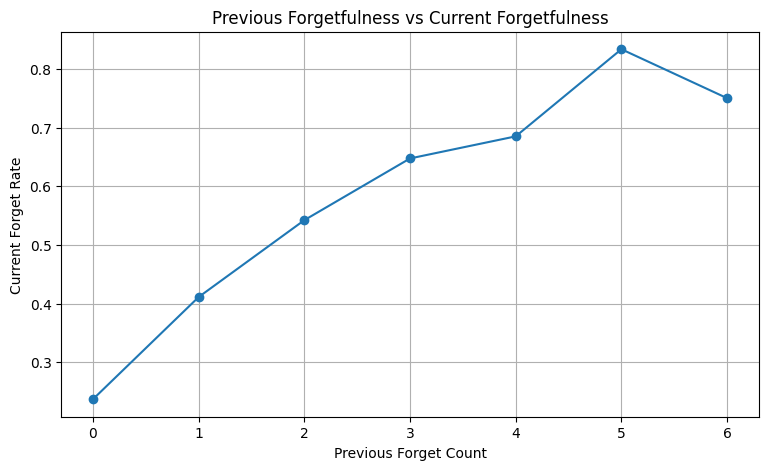

In [ ]:
history_forget_rate = (
    df.groupby("previous_forget_count")["forgot"]
    .mean()
)

print("Forget rate based on previous forget count:")
print((history_forget_rate * 100).round(2))
plt.figure(figsize=(9, 5))

history_forget_rate.plot(marker="o")

plt.title("Previous Forgetfulness vs Current Forgetfulness")
plt.xlabel("Previous Forget Count")
plt.ylabel("Current Forget Rate")
plt.grid(True)
plt.show()

item_relevance
0.010    0.846154
0.016    0.000000
0.019    1.000000
0.024    1.000000
0.025    1.000000
0.027    1.000000
0.031    1.000000
0.035    1.000000
0.036    1.000000
0.038    0.000000
Name: forgot, dtype: float64


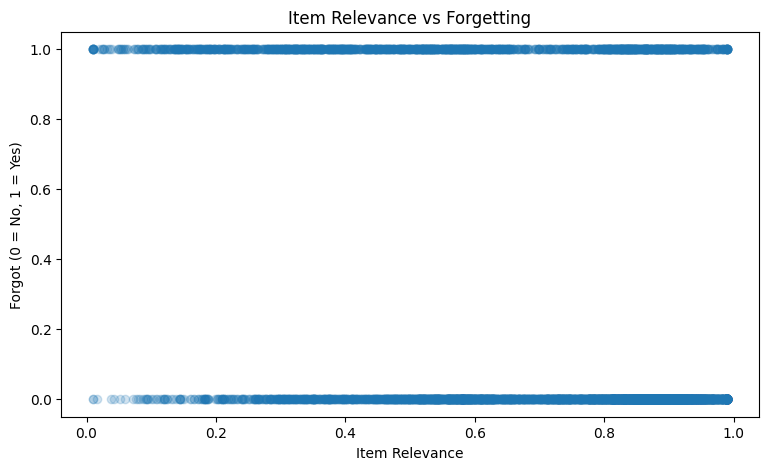

In [ ]:
relevance_forget_rate = (
    df.groupby("item_relevance")["forgot"]
    .mean()
)

print(relevance_forget_rate.head(10))
plt.figure(figsize=(9, 5))

plt.scatter(
    df["item_relevance"],
    df["forgot"],
    alpha=0.2
)

plt.title("Item Relevance vs Forgetting")
plt.xlabel("Item Relevance")
plt.ylabel("Forgot (0 = No, 1 = Yes)")
plt.show()

forgot
0    3318
1    1682
Name: count, dtype: int64


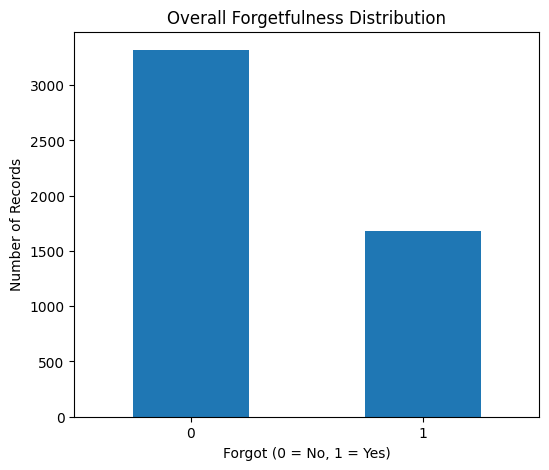

In [ ]:
forgot_counts = df["forgot"].value_counts()

print(forgot_counts)
plt.figure(figsize=(6, 5))

forgot_counts.plot(kind="bar")

plt.title("Overall Forgetfulness Distribution")
plt.xlabel("Forgot (0 = No, 1 = Yes)")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

# Phase 3 — Feature Engineering and Data Preprocessing

In [ ]:
# Features and target

X = df.drop(columns=["forgot", "trip_id"])
y = df["forgot"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X):
['day_of_week', 'destination', 'time_of_day', 'weather', 'trip_duration', 'item', 'item_importance', 'item_relevance', 'times_carried_before', 'previous_forget_count']

Target (y):
forgot

X shape: (5000, 10)
y shape: (5000,)


In [ ]:
categorical_features = [
    "day_of_week",
    "destination",
    "time_of_day",
    "weather",
    "trip_duration",
    "item"
]

numerical_features = [
    "item_importance",
    "item_relevance",
    "times_carried_before",
    "previous_forget_count"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['day_of_week', 'destination', 'time_of_day', 'weather', 'trip_duration', 'item']

Numerical features:
['item_importance', 'item_relevance', 'times_carried_before', 'previous_forget_count']


In [ ]:
for column in categorical_features:
    print(f"\n{column}:")
    print(df[column].unique())


day_of_week:
['Monday' 'Saturday' 'Friday' 'Thursday' 'Sunday' 'Tuesday' 'Wednesday']

destination:
['Gym' 'College' 'Other' 'Office' 'Shopping' 'Travel' 'Family_Event'
 'Friends_House']

time_of_day:
['Morning' 'Night' 'Afternoon' 'Evening']

weather:
['Sunny' 'Hot' 'Cold' 'Rainy' 'Cloudy']

trip_duration:
['Medium' 'Short' 'Long']

item:
['Phone' 'ID_Card' 'Keys' 'Water_Bottle' 'Notebook' 'Laptop' 'Wallet'
 'Earphones' 'Charger' 'Umbrella']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4000
Testing samples: 1000


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (4000, 41)
Processed testing shape: (1000, 41)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("Models imported successfully!")

Models imported successfully!


In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

decision_tree_model.fit(X_train_processed, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
logistic_predictions = logistic_model.predict(X_test_processed)

decision_tree_predictions = decision_tree_model.predict(X_test_processed)

random_forest_predictions = random_forest_model.predict(X_test_processed)

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Evaluation metrics imported!")

Evaluation metrics imported!


In [ ]:
models = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions
}

results = []

for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.742,0.657258,0.485119,0.558219
1,Decision Tree,0.704,0.578125,0.440476,0.500000
2,Random Forest,0.739,0.650602,0.482143,0.553846


In [ ]:
print("========== LOGISTIC REGRESSION ==========")
print(classification_report(y_test, logistic_predictions))

print("========== DECISION TREE ==========")
print(classification_report(y_test, decision_tree_predictions))

print("========== RANDOM FOREST ==========")
print(classification_report(y_test, random_forest_predictions))

========== LOGISTIC REGRESSION ==========
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       664
           1       0.66      0.49      0.56       336

    accuracy                           0.74      1000
   macro avg       0.71      0.68      0.69      1000
weighted avg       0.73      0.74      0.73      1000

========== DECISION TREE ==========
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       664
           1       0.58      0.44      0.50       336

    accuracy                           0.70      1000
   macro avg       0.66      0.64      0.64      1000
weighted avg       0.69      0.70      0.69      1000

========== RANDOM FOREST ==========
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       664
           1       0.65      0.48      0.55       336

    accuracy                           0.74      1000
   macro avg  

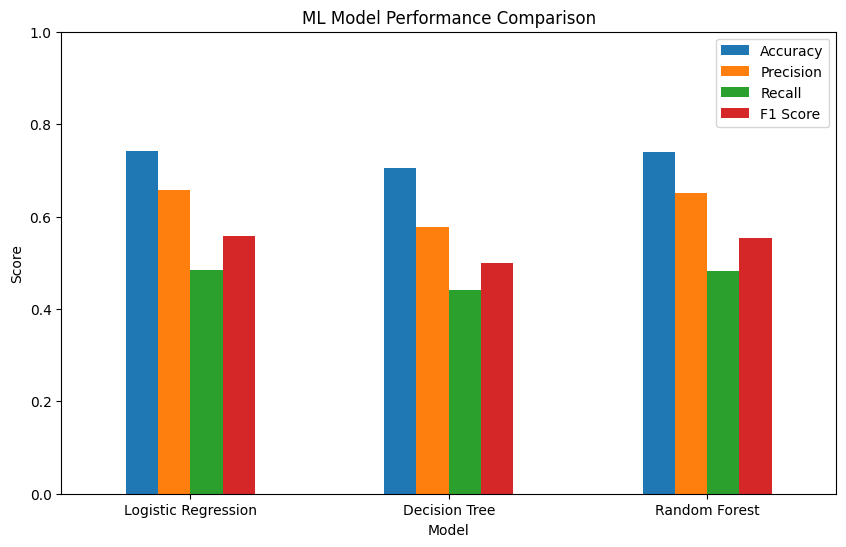

In [ ]:
results_plot = results_df.set_index("Model")

results_plot[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

Confusion Matrix:
[[579  85]
 [173 163]]


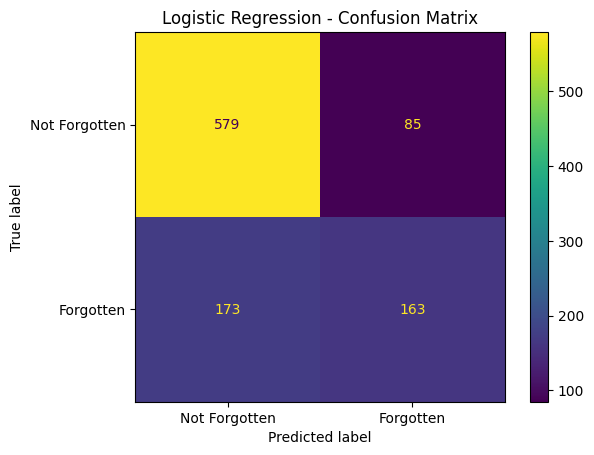

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, logistic_predictions)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Forgotten", "Forgotten"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
logistic_probabilities = logistic_model.predict_proba(X_test_processed)

print(logistic_probabilities[:10])

[[0.81464248 0.18535752]
 [0.44695854 0.55304146]
 [0.46467152 0.53532848]
 [0.82073356 0.17926644]
 [0.36043161 0.63956839]
 [0.76629486 0.23370514]
 [0.28368922 0.71631078]
 [0.71408697 0.28591303]
 [0.56017443 0.43982557]
 [0.85221624 0.14778376]]


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

probabilities = logistic_model.predict_proba(X_test_processed)[:, 1]

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

for threshold in thresholds:
    predictions = (probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.30,0.532051,0.741071,0.619403
1,0.35,0.584158,0.702381,0.637838
2,0.40,0.606145,0.645833,0.625360
3,0.45,0.620000,0.553571,0.584906
4,0.50,0.657258,0.485119,0.558219
5,0.55,0.698492,0.413690,0.519626
6,0.60,0.712418,0.324405,0.445808
7,0.65,0.752294,0.244048,0.368539
8,0.70,0.770270,0.169643,0.278049


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

In [ ]:
# Features and target
X = df.drop(columns=["forgot", "trip_id"])
y = df["forgot"]

# Use trip_id as the grouping variable
groups = df["trip_id"]

# Create a group-based train/test split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nUnique training trips:", df.iloc[train_idx]["trip_id"].nunique())
print("Unique testing trips:", df.iloc[test_idx]["trip_id"].nunique())

Training samples: 4022
Testing samples: 978

Unique training trips: 876
Unique testing trips: 219


In [ ]:
train_trips = set(df.iloc[train_idx]["trip_id"])
test_trips = set(df.iloc[test_idx]["trip_id"])

overlap = train_trips.intersection(test_trips)

print("Trips appearing in both training and testing:", len(overlap))

Trips appearing in both training and testing: 0


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (4022, 41)
Processed testing shape: (978, 41)


In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train
logistic_model.fit(X_train_processed, y_train)
decision_tree_model.fit(X_train_processed, y_train)
random_forest_model.fit(X_train_processed, y_train)

print("All three models retrained successfully!")

All three models retrained successfully!


In [ ]:
logistic_predictions = logistic_model.predict(X_test_processed)
decision_tree_predictions = decision_tree_model.predict(X_test_processed)
random_forest_predictions = random_forest_model.predict(X_test_processed)

print("New predictions generated!")

New predictions generated!


In [ ]:
models = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions
}

results = []

for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.740286,0.652893,0.481707,0.554386
1,Decision Tree,0.717791,0.601562,0.469512,0.527397
2,Random Forest,0.749489,0.676596,0.484756,0.564831


Random Forest Confusion Matrix:
[[574  76]
 [169 159]]


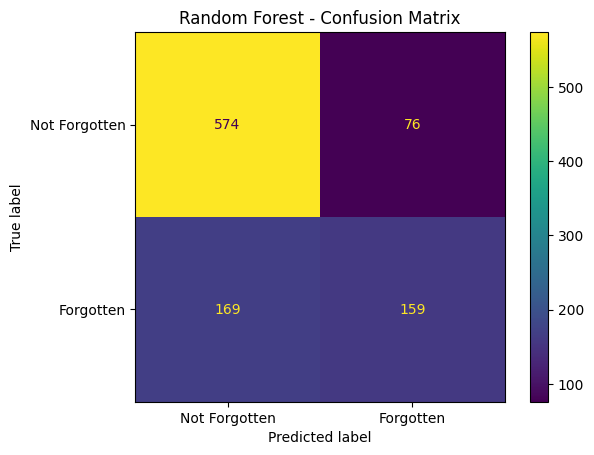

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, random_forest_predictions)

print("Random Forest Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Not Forgotten", "Forgotten"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
rf_probabilities = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("First 10 forgetting probabilities:")
print(rf_probabilities[:10])

First 10 forgetting probabilities:
[0.18178146 0.3315029  0.18190855 0.23847224 0.11277823 0.3922284
 0.56936083 0.75905706 0.63825249 0.66657944]


In [ ]:
print("Minimum probability:", rf_probabilities.min())
print("Maximum probability:", rf_probabilities.max())
print("Average probability:", rf_probabilities.mean())

Minimum probability: 0.049865123537794466
Maximum probability: 0.8598008219357264
Average probability: 0.33878685277145554


In [ ]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of processed features: 41

First 20 features:
['categorical__day_of_week_Friday' 'categorical__day_of_week_Monday'
 'categorical__day_of_week_Saturday' 'categorical__day_of_week_Sunday'
 'categorical__day_of_week_Thursday' 'categorical__day_of_week_Tuesday'
 'categorical__day_of_week_Wednesday' 'categorical__destination_College'
 'categorical__destination_Family_Event'
 'categorical__destination_Friends_House' 'categorical__destination_Gym'
 'categorical__destination_Office' 'categorical__destination_Other'
 'categorical__destination_Shopping' 'categorical__destination_Travel'
 'categorical__time_of_day_Afternoon' 'categorical__time_of_day_Evening'
 'categorical__time_of_day_Morning' 'categorical__time_of_day_Night'
 'categorical__weather_Cloudy']


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
38,remainder__item_relevance,0.201032
37,remainder__item_importance,0.136627
39,remainder__times_carried_before,0.122033
40,remainder__previous_forget_count,0.076941
33,categorical__item_Phone,0.029136
17,categorical__time_of_day_Morning,0.019131
24,categorical__trip_duration_Long,0.016429
25,categorical__trip_duration_Medium,0.016106
22,categorical__weather_Rainy,0.015739
15,categorical__time_of_day_Afternoon,0.015482


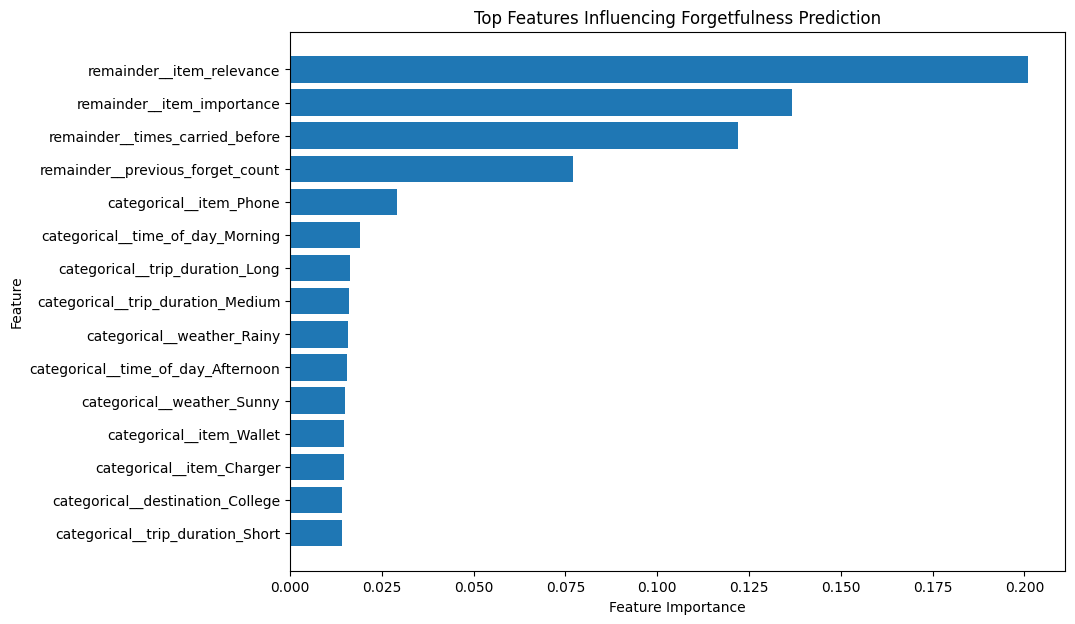

In [ ]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Features Influencing Forgetfulness Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
thresholds = [
    0.20, 0.25, 0.30, 0.35,
    0.40, 0.45, 0.50, 0.55,
    0.60, 0.65, 0.70
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        rf_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.20,0.421991,0.865854,0.567433
1,0.25,0.469027,0.807927,0.593505
2,0.30,0.502083,0.734756,0.596535
3,0.35,0.545906,0.670732,0.601915
4,0.40,0.582133,0.615854,0.598519
5,0.45,0.619863,0.551829,0.583871
6,0.50,0.676596,0.484756,0.564831
7,0.55,0.695187,0.396341,0.504854
8,0.60,0.715328,0.298780,0.421505
9,0.65,0.743902,0.185976,0.297561


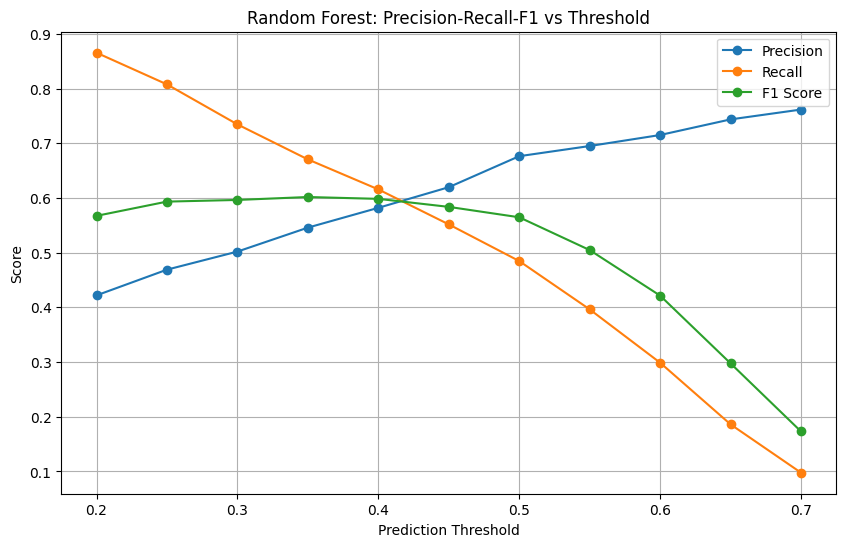

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.title("Random Forest: Precision-Recall-F1 vs Threshold")
plt.legend()
plt.grid(True)

plt.show()

# Phase 7 — Final Forgetfulness Prediction System
## Converting ML Probabilities into Risk Levels

In [ ]:
FINAL_THRESHOLD = 0.35

print("Final prediction threshold:", FINAL_THRESHOLD)

Final prediction threshold: 0.35


In [ ]:
def predict_forgetfulness(
    day_of_week,
    destination,
    time_of_day,
    weather,
    trip_duration,
    item,
    item_importance,
    item_relevance,
    times_carried_before,
    previous_forget_count
):

    # Create input dataframe
    input_data = pd.DataFrame([{
        "day_of_week": day_of_week,
        "destination": destination,
        "time_of_day": time_of_day,
        "weather": weather,
        "trip_duration": trip_duration,
        "item": item,
        "item_importance": item_importance,
        "item_relevance": item_relevance,
        "times_carried_before": times_carried_before,
        "previous_forget_count": previous_forget_count
    }])

    # Apply the same preprocessing used during training
    input_processed = preprocessor.transform(input_data)

    # Get probability of forgetting
    probability = random_forest_model.predict_proba(
        input_processed
    )[0][1]

    # Apply our selected threshold
    prediction = int(probability >= FINAL_THRESHOLD)

    return probability, prediction

In [ ]:
probability, prediction = predict_forgetfulness(
    day_of_week="Monday",
    destination="College",
    time_of_day="Morning",
    weather="Sunny",
    trip_duration="Medium",
    item="Charger",
    item_importance=0.8,
    item_relevance=0.9,
    times_carried_before=5,
    previous_forget_count=3
)

print("Forgetfulness probability:", round(probability * 100, 2), "%")
print("Prediction:", "FORGOT" if prediction == 1 else "NOT FORGOT")

Forgetfulness probability: 51.05 %
Prediction: FORGOT


In [ ]:
def get_risk_level(probability):

    if probability >= 0.60:
        return "HIGH"

    elif probability >= 0.35:
        return "MEDIUM"

    else:
        return "LOW"
risk = get_risk_level(probability)

print("Risk Level:", risk)

Risk Level: MEDIUM


In [ ]:
items = [
    "Phone",
    "Wallet",
    "Keys",
    "Charger",
    "Water_Bottle",
    "Earphones",
    "Laptop",
    "Notebook",
    "Umbrella",
    "ID_Card"
]

print("Items to evaluate:")
print(items)

Items to evaluate:
['Phone', 'Wallet', 'Keys', 'Charger', 'Water_Bottle', 'Earphones', 'Laptop', 'Notebook', 'Umbrella', 'ID_Card']


In [ ]:
def generate_forgetfulness_check(
    day_of_week,
    destination,
    time_of_day,
    weather,
    trip_duration
):

    predictions = []

    for item in items:

        # Get typical item values from our dataset
        item_data = df[df["item"] == item]

        item_importance = item_data["item_importance"].mean()
        item_relevance = item_data["item_relevance"].mean()
        times_carried_before = item_data["times_carried_before"].mean()
        previous_forget_count = item_data["previous_forget_count"].mean()

        probability, prediction = predict_forgetfulness(
            day_of_week,
            destination,
            time_of_day,
            weather,
            trip_duration,
            item,
            item_importance,
            item_relevance,
            times_carried_before,
            previous_forget_count
        )

        predictions.append({
            "Item": item,
            "Forget Probability": probability,
            "Risk": get_risk_level(probability)
        })

    result = pd.DataFrame(predictions)

    result = result.sort_values(
        by="Forget Probability",
        ascending=False
    ).reset_index(drop=True)

    return result

In [ ]:
forgetfulness_check = generate_forgetfulness_check(
    day_of_week="Monday",
    destination="College",
    time_of_day="Morning",
    weather="Sunny",
    trip_duration="Medium"
)

forgetfulness_check

,Item,Forget Probability,Risk
0,Umbrella,0.626441,HIGH
1,Earphones,0.593088,MEDIUM
2,Water_Bottle,0.538886,MEDIUM
3,Charger,0.487360,MEDIUM
4,Notebook,0.420005,MEDIUM
5,Laptop,0.351999,MEDIUM
6,ID_Card,0.193420,LOW
7,Keys,0.160856,LOW
8,Wallet,0.149069,LOW
9,Phone,0.067244,LOW


In [ ]:
item_history = (
    df.groupby("item")
      .agg(
          previous_forget_count=("previous_forget_count", "mean"),
          times_carried_before=("times_carried_before", "mean"),
          item_importance=("item_importance", "mean")
      )
      .reset_index()
)

item_history

,item,previous_forget_count,times_carried_before,item_importance
0,Charger,1.286573,11.184369,0.55
1,Earphones,1.137255,9.603486,0.40
2,ID_Card,0.373898,11.746032,0.90
3,Keys,0.099222,9.844358,0.93
4,Laptop,0.810811,11.476658,0.80
5,Notebook,1.051988,10.908257,0.50
6,Phone,0.059818,13.292588,0.98
7,Umbrella,1.529577,9.774648,0.35
8,Wallet,0.073650,11.361702,0.95
9,Water_Bottle,1.073171,10.487805,0.45


In [ ]:
def generate_personalized_check(
    day_of_week,
    destination,
    time_of_day,
    weather,
    trip_duration
):

    predictions = []

    for item in items:

        # Find historical information for this item
        item_rows = df[df["item"] == item]

        if len(item_rows) == 0:
            print(f"Warning: {item} not found in dataset")
            continue

        item_importance = item_rows["item_importance"].mean()
        times_carried_before = item_rows["times_carried_before"].mean()
        previous_forget_count = item_rows["previous_forget_count"].mean()

        # Use the model to predict
        probability, prediction = predict_forgetfulness(
            day_of_week=day_of_week,
            destination=destination,
            time_of_day=time_of_day,
            weather=weather,
            trip_duration=trip_duration,
            item=item,
            item_importance=item_importance,
            item_relevance=1.0,
            times_carried_before=times_carried_before,
            previous_forget_count=previous_forget_count
        )

        predictions.append({
            "Item": item,
            "Forget Probability": probability * 100,
            "Risk": get_risk_level(probability)
        })

    result = pd.DataFrame(predictions)

    result = result.sort_values(
        by="Forget Probability",
        ascending=False
    ).reset_index(drop=True)

    result["Forget Probability"] = result["Forget Probability"].round(2)

    return result

In [ ]:
def create_forgetfulness_report(
    day_of_week,
    destination,
    time_of_day,
    weather,
    trip_duration
):

    result = generate_personalized_check(
        day_of_week=day_of_week,
        destination=destination,
        time_of_day=time_of_day,
        weather=weather,
        trip_duration=trip_duration
    )

    print("=" * 55)
    print("        🎒 WHAT DID I FORGET?")
    print("=" * 55)

    print(f"\n📍 Destination : {destination}")
    print(f"📅 Day         : {day_of_week}")
    print(f"🕐 Time        : {time_of_day}")
    print(f"🌤️ Weather     : {weather}")
    print(f"⏱️ Trip        : {trip_duration}")

    print("\n" + "-" * 55)
    print("              FORGETFULNESS ALERT")
    print("-" * 55)

    high_risk = result[result["Risk"] == "HIGH"]
    medium_risk = result[result["Risk"] == "MEDIUM"]

    if len(high_risk) > 0:
        print("\n🔴 HIGH RISK — Check these first:")

        for _, row in high_risk.iterrows():
            print(
                f"   • {row['Item']}: "
                f"{row['Forget Probability']:.1f}%"
            )

    if len(medium_risk) > 0:
        print("\n🟡 MEDIUM RISK:")

        for _, row in medium_risk.iterrows():
            print(
                f"   • {row['Item']}: "
                f"{row['Forget Probability']:.1f}%"
            )

    print("\n" + "-" * 55)
    print("              COMPLETE CHECKLIST")
    print("-" * 55)

    display(result)

    return result

In [ ]:
college_report = create_forgetfulness_report(
    day_of_week="Monday",
    destination="College",
    time_of_day="Morning",
    weather="Sunny",
    trip_duration="Medium"
)

        🎒 WHAT DID I FORGET?

📍 Destination : College
📅 Day         : Monday
🕐 Time        : Morning
🌤️ Weather     : Sunny
⏱️ Trip        : Medium

-------------------------------------------------------
              FORGETFULNESS ALERT
-------------------------------------------------------

🟡 MEDIUM RISK:
   • Earphones: 48.5%
   • Umbrella: 48.5%
   • Water_Bottle: 44.5%
   • Charger: 43.1%

-------------------------------------------------------
              COMPLETE CHECKLIST
-------------------------------------------------------


,Item,Forget Probability,Risk
0,Earphones,48.51,MEDIUM
1,Umbrella,48.49,MEDIUM
2,Water_Bottle,44.50,MEDIUM
3,Charger,43.08,MEDIUM
4,Notebook,33.64,LOW
5,Laptop,28.01,LOW
6,Keys,20.62,LOW
7,ID_Card,15.62,LOW
8,Wallet,14.94,LOW
9,Phone,8.39,LOW


In [ ]:
def get_top_reminders(result, n=5):

    top_items = result.head(n).copy()

    print("\n🎒 TOP ITEMS TO CHECK BEFORE LEAVING:\n")

    for i, (_, row) in enumerate(top_items.iterrows(), start=1):

        print(
            f"{i}. {row['Item']} "
            f"— {row['Forget Probability']:.1f}% "
            f"({row['Risk']} RISK)"
        )

    return top_items

In [ ]:
top_reminders = get_top_reminders(
    college_report,
    n=5
)


🎒 TOP ITEMS TO CHECK BEFORE LEAVING:

1. Earphones — 48.5% (MEDIUM RISK)
2. Umbrella — 48.5% (MEDIUM RISK)
3. Water_Bottle — 44.5% (MEDIUM RISK)
4. Charger — 43.1% (MEDIUM RISK)
5. Notebook — 33.6% (LOW RISK)


In [ ]:
import joblib

joblib.dump(
    random_forest_model,
    "random_forest_model.pkl"
)

joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [ ]:
import joblib

# Load the saved model
loaded_model = joblib.load("random_forest_model.pkl")

# Load the saved preprocessing pipeline
loaded_preprocessor = joblib.load("preprocessor.pkl")

print("Model loaded successfully!")
print("Preprocessor loaded successfully!")

Model loaded successfully!
Preprocessor loaded successfully!


In [ ]:
test_predictions = loaded_model.predict(
    X_test_processed
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(
    "Loaded model accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

Loaded model accuracy: 74.95 %


In [ ]:
import os

print("Files created:")

for file in [
    "random_forest_model.pkl",
    "preprocessor.pkl"
]:

    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

Files created:
✅ random_forest_model.pkl
✅ preprocessor.pkl
